## **Assignment Group 2: Predicting House Prices**
*By Tom Biefel, Kishan Dhulashia, Álvaro Perez La Rosa, Robyn Rothlin, Carlos Suarez Álvarez,  and Natalia Urrea Lopez*

Link to Canva Presenation: https://www.canva.com/design/DAHAc1_dx-8/YY5WRr67DB5GUzVfNlceIQ/edit?utm_content=DAHAc1_dx-8&utm_campaign=designshare&utm_medium=link2&utm_source=sharebutton

--------------

**Chosen Dataset**: Housing Prices

**Source**: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset/data

**Objective**: The objective of this project is to predict house prices based on structural and contextual housing attributes. It will be a multiple regression problem with the target variable being `price`

**Research Question**: Can house prices be accurately predicted from structural and amenity-based property characteristics using regression models?

**Why?**: Predicting accurate house prices is useful for 
i) buyers and sellers, 
ii) real estate agencies, and
iii) financial institutions, ensuring fair pricing and transparency for all parties involved.

--------------


### **Notebook Structure**

This analysis follows a systematic approach to develop and compare multiple regression models:

**1. Data Loading & Setup**
- Import necessary libraries (pandas, sklearn, matplotlib, seaborn)
- Load housing dataset directly from Kaggle

**2. Exploratory Data Analysis (EDA)**
- Inspect data structure, types, and completeness
- Analyze distributions of numerical features (price, area, bedrooms, bathrooms, stories, parking)
- Examine target variable (price) for outliers and skewness
- Check for multicollinearity among features

**3. Model Development**

We develop four distinct regression models with progressive feature engineering:

- **Model 1 - Baseline:** Standard preprocessing only (binary encoding, one-hot encoding, scaling)
- **Model 2 - Log Transformations:** Add log transformations to both area and price to address right skewness
- **Model 3 - Feature Selection:** Model 2 + LassoCV regularization to identify and retain most important features
- **Model 4 - Outlier Removal:** Model 2 + Outlier removal
- **Model 5 - K-Fold:** Model 2 + K-fold Cross-Validation

**4. Model Evaluation & Comparison**
- Compare models using R², Adjusted R², MAE, and RMSE
- Analyze residuals for each model to validate assumptions
- Identify best-performing model and key insights

--------------------

### **Data Loading & Setup**

*Goal: Ensure that we have the necessary means (Python libraries and data) to establish our model*

In [162]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [163]:
# Importing all the needed libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import KFold, cross_validate
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from kagglehub import KaggleDatasetAdapter
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectFromModel


In [164]:
# directly access the dataset though Kaggle connection

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "yasserh/housing-prices-dataset",
    "Housing.csv",
)

--------------

### **Data Inspection/ Understanding (EDA)**
*Goal: understand what data we actually have before transforming anything*

Before anything, we have a quick inspection of our data by calling `df.head()`, allowing us to gather a brief understanding of how the data looks like - data types, columns etc. We then verify the data types using `df.info()`, which allows us to distinguish between *numerical*, *binary*, and *categorical* data. We also use `df.shape` to understand the size of the dataset and how many records/ features we are dealing with. `df.describe()` allows us to collect summary statistics of our numerical data to understand the distribution of each. We also must check for any *NaN* values, in case we must fill these missing values in a later (Data processing) step.To conclude our EDA phase, even though we already have the statistical summary of the numerical columns, we **visualize them using a histogram**, enabeling better and faster understanding of any potential transformation that must be undertaken to for example reduce skewness or magnitude effects. We also plot in detail the **discribution of our target variable (price) using a boxplot**, to quickly recognise any outliers. Finally, we use a **correlation matrix to check the variables for multicollinearity**.

In [165]:
# Quick inspection of data
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [166]:
# Understanding data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


**Variable Types in our dataset**

Numeric variables: `price` ,`area`, `bedrooms`, `bathrooms`, `stories`, `parking`

Binary (True/False): `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`

Nominal categorical variable: `furnishingstatus`

In [167]:
print(df.shape)
print(f"The datset has {df.shape[0]} records and {df.shape[1]} columns.")

(545, 13)
The datset has 545 records and 13 columns.


In [168]:
# Check statistical measures for numerical columns
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [169]:
# Checking for any missing values
nan_count = df.isna().sum()
print(f"Missing values per column: \n{nan_count}")

Missing values per column: 
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


We have no missing values, therefore do not need to take any measures to drop/ impute any numbers.

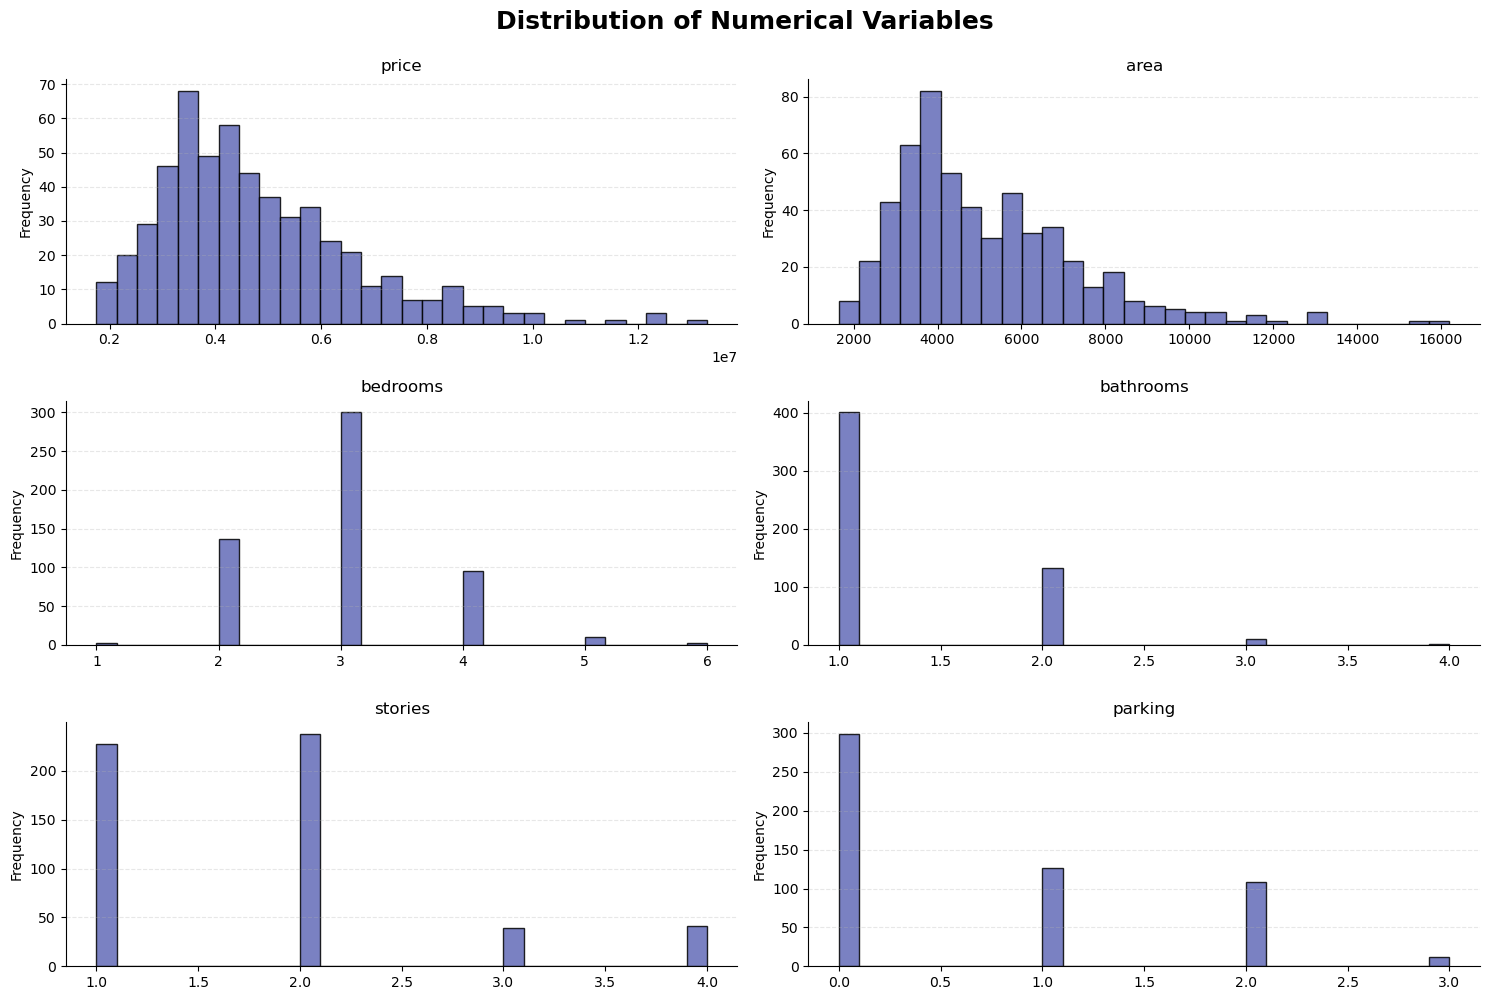

In [170]:
# Plot distributions of numerical data to understand distribution

num_features = [
    "price",
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

# Create histograms 
axes = df[num_features].hist(bins=30, figsize=(15, 10), color='#636bb8', edgecolor='black', alpha=0.85, grid=False)

# Format subplots
for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylabel('Frequency', fontsize=10)

plt.suptitle("Distribution of Numerical Variables", fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

We can see that both price and area are right skewed, which indicates that we might have to do a **log-transformation** later on to reduce the skew. We can also see that the remaining numerical columns (besrooms, bathrooms, stories, and parking) are discrete and rather low.

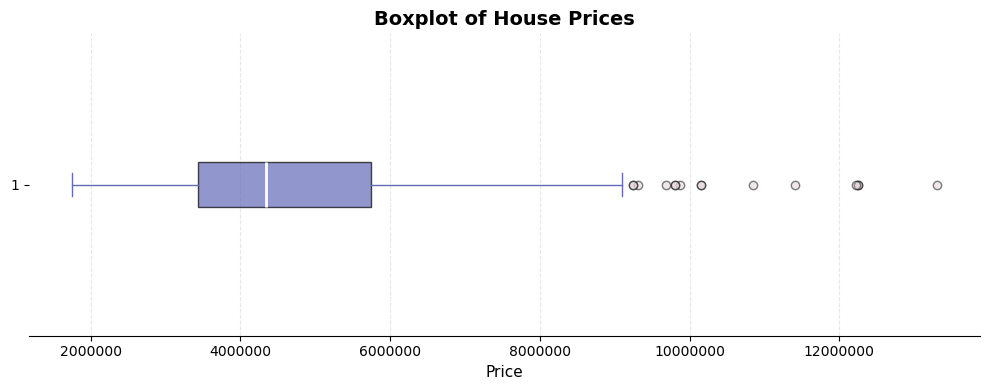

In [171]:
# Closer analysis of the target variable (price)

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(df["price"], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#636bb8', alpha=0.7),
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#636bb8'),
                capprops=dict(color='#636bb8'),
                flierprops=dict(markerfacecolor='#e0d1d4', marker='o', markersize=6, alpha=0.5))

ax.set_title("Boxplot of House Prices", fontsize=14, fontweight='bold')
ax.set_xlabel("Price", fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

This boxplot allows us to speficy the distribution of our target variable. We can quickly see that there is a rather large range of values that the target can take, with some rather large outliers, which skew the whole data to the right. This could potentially impact the model training, and lead to over- or underestimation of a "normal" datapoint.

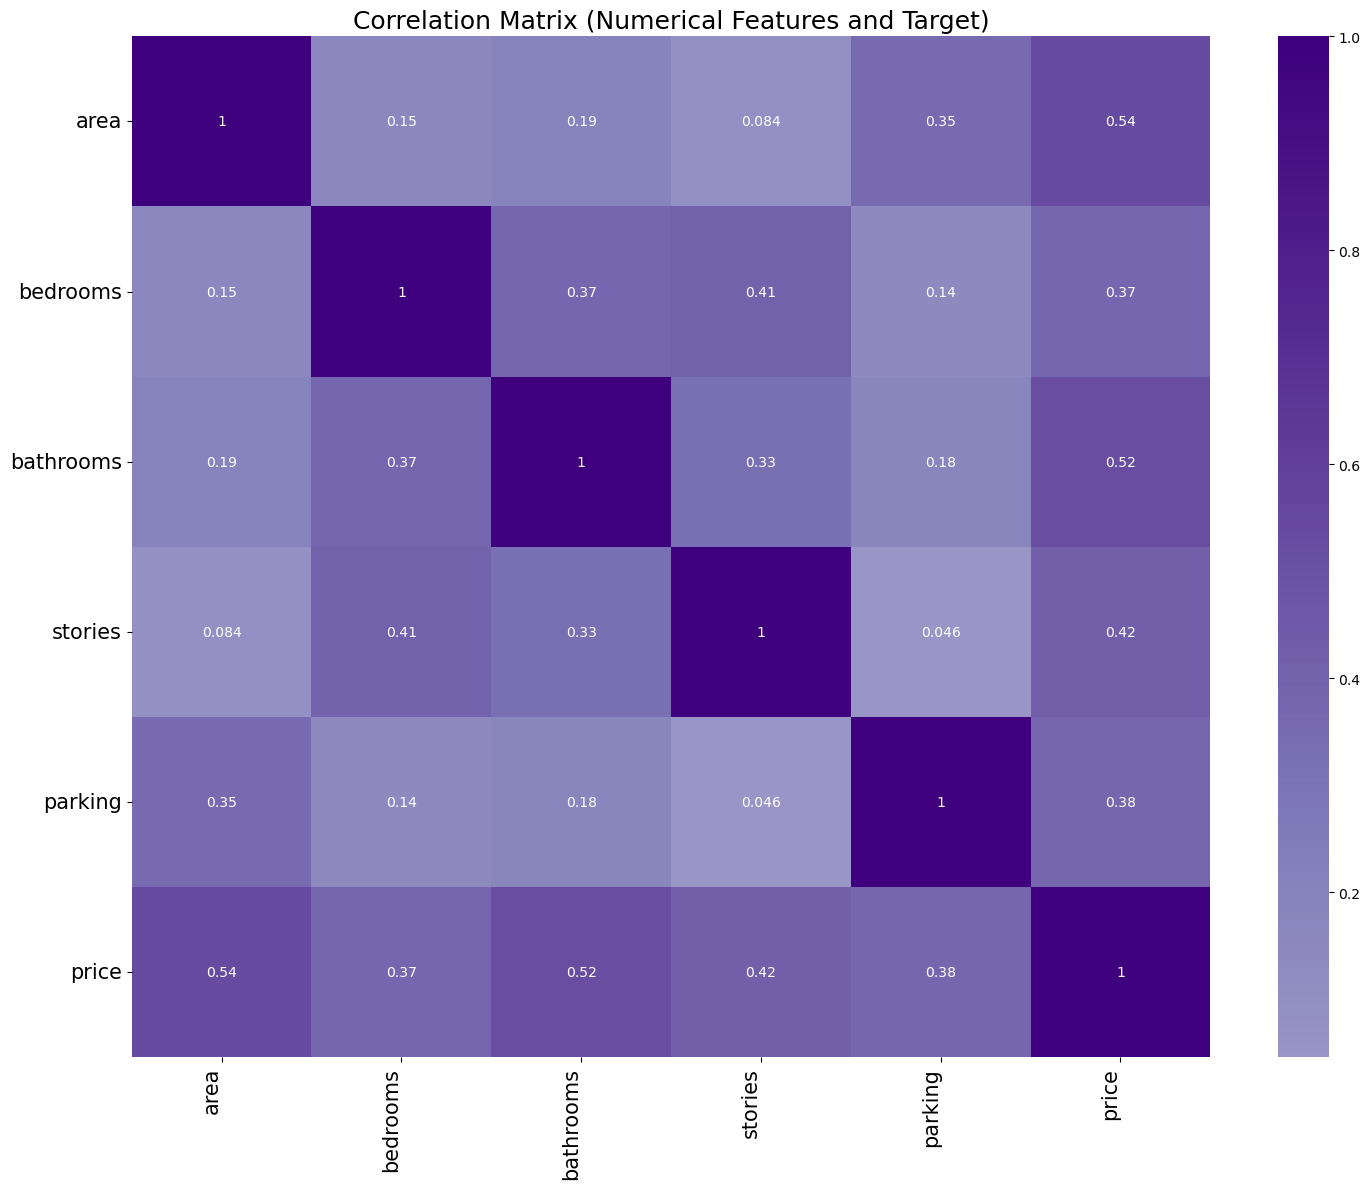

In [172]:
# Correlation matrix to check multicollinearity

numeric_cols = ["area", "bedrooms", "bathrooms", "stories", "parking"]
TARGET = "price"

corr = df[numeric_cols + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(
    corr,
    cmap="Purples",
    center=0,
    annot=True,
    square=False,
    ax=ax
)

ax.set_title("Correlation Matrix (Numerical Features and Target)", fontsize=18)

ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [173]:
# Check whether there are any numerical featues that are strongly correlated with each other

# Define correlation threhold --> above 80%
CORR_THRESHOLD = 0.80
corr = df[numeric_cols].corr().abs()

# Showcase high correlation pairs
high_corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .loc[lambda x: x > CORR_THRESHOLD]
)

print(f"Highly correlated numeric feature pairs (>|{CORR_THRESHOLD}|):")
print(high_corr_pairs)

Highly correlated numeric feature pairs (>|0.8|):
Series([], dtype: float64)


After examining the correlation matrix, we find out that there is no multicollinearity present in this dataset, which means that as of this moment, we do not have to drop any features.

**EDA Insights:**

*Dataset completeness*
- The dataset contains 545 observations
- No missing values are present in either numerical or categorical variables

*Target variable: `price`*
- House prices range from 1.75M to 13.3M, with a median of 4.34M
- The distribution of prices is strongly right-skewed, as confirmed by both the histogram and boxplot (some high-value outliers are present in the upper tail)
- This skewness and presence of extreme values may affect linear regression assumptions

*Numerical independent variables*
- `area` shows substantial variability (from 1,650 to 16,200) and is also right-skewed, with a long upper tail
- `bedrooms`, `bathrooms`, `stories`, and `parking` take discrete, low integer values, indicating count-type features rather than continuous measurements

----------------

### **Shared Train/Test Split**

Define a single train/test split to be used by all models for fair comparison.

In [174]:
# Define target and features, then create a single train/test split for all models
TARGET = "price"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET]

# Single train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Train set size: (436, 12)
Test set size: (109, 12)


In [175]:
X_train_1 = X_train.copy()
X_test_1 = X_test.copy()
y_train_1 = y_train.copy()
y_test_1 = y_test.copy()
print(f"Model 1: {X_train_1.shape}, {X_test_1.shape}")

X_train_2 = X_train.copy()
X_test_2 = X_test.copy()
y_train_2 = y_train.copy()
y_test_2 = y_test.copy()
print(f"Model 2: {X_train_2.shape}, {X_test_2.shape}")

X_train_3 = X_train.copy()
X_test_3 = X_test.copy()
y_train_3 = y_train.copy()
y_test_3 = y_test.copy()
print(f"Model 3: {X_train_3.shape}, {X_test_3.shape}")

X_train_4 = X_train.copy()
X_test_4 = X_test.copy()
y_train_4 = y_train.copy()
y_test_4 = y_test.copy()
print(f"Model 4: {X_train_4.shape}, {X_test_4.shape}")

Model 1: (436, 12), (109, 12)
Model 2: (436, 12), (109, 12)
Model 3: (436, 12), (109, 12)
Model 4: (436, 12), (109, 12)


### **Model 1: Baseline**

This Multiple Linear Regression Model will focus on the most basic transformation of the independent variables:
- Binary encoding + one-hot encoding + StandardScaler on numerics
- No log transformation on target
- All original features

#### Data Preparation

In [176]:
# Encode binary columns (yes/no --> 1/0)
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]

for d in (X_train_1, X_test_1):
    d[binary_cols] = d[binary_cols].replace({"yes": 1, "no": 0})

C:\Users\rothl\AppData\Local\Temp\ipykernel_45276\1260408089.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d[binary_cols] = d[binary_cols].replace({"yes": 1, "no": 0})
C:\Users\rothl\AppData\Local\Temp\ipykernel_45276\1260408089.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d[binary_cols] = d[binary_cols].replace({"yes": 1, "no": 0})


In [177]:
# Hot encoding nominal categorical (furniture)

ohe = OneHotEncoder(drop="first", sparse_output=False,handle_unknown='ignore')

# Fit on train only
train_ohe_1 = ohe.fit_transform(X_train_1[["furnishingstatus"]])
test_ohe_1  = ohe.transform(X_test_1[["furnishingstatus"]])

# Make DataFrames with same columns
ohe_cols_1 = ohe.get_feature_names_out(["furnishingstatus"])

train_ohe_df_1 = pd.DataFrame(train_ohe_1, columns=ohe_cols_1, index=X_train_1.index)
test_ohe_df_1  = pd.DataFrame(test_ohe_1,  columns=ohe_cols_1, index=X_test_1.index)

# Drop original col + concat encoded
X_train_1 = pd.concat([X_train_1.drop(columns=["furnishingstatus"]), train_ohe_df_1], axis=1)
X_test_1  = pd.concat([X_test_1.drop(columns=["furnishingstatus"]),  test_ohe_df_1], axis=1)


In [178]:
# Scale numerical independent variables

num_cols = ["area", "bedrooms", "bathrooms", "stories", "parking"]

scaler_1 = StandardScaler()

X_train_1[num_cols] = scaler_1.fit_transform(X_train_1[num_cols])  # fit on train
X_test_1[num_cols]  = scaler_1.transform(X_test_1[num_cols])       # transform test

In [179]:
X_train_1

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,0.384168,0.055271,1.539173,2.587644,1,0,0,0,1,0.367957,0,0.0,0.0
93,0.929181,0.055271,1.539173,-0.912499,1,0,1,0,1,2.709987,0,1.0,0.0
335,-0.607755,-1.283514,-0.557950,-0.912499,1,0,1,0,1,1.538972,0,0.0,0.0
412,-1.155492,0.055271,-0.557950,0.254215,1,0,1,0,0,-0.803059,1,0.0,1.0
471,-0.637730,0.055271,-0.557950,0.254215,1,0,0,0,0,-0.803059,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.384168,1.394055,1.539173,2.587644,1,0,0,0,1,-0.803059,0,0.0,1.0
106,0.134371,1.394055,1.539173,-0.912499,1,0,1,0,1,-0.803059,1,1.0,0.0
270,-0.297097,0.055271,1.539173,1.420929,1,0,0,1,0,0.367957,0,0.0,0.0
435,-0.506019,-1.283514,-0.557950,-0.912499,1,0,0,0,0,-0.803059,0,0.0,1.0


In [180]:
y_train_1

46     7525000
93     6300000
335    3920000
412    3430000
471    3010000
        ...   
71     6755000
106    6160000
270    4340000
435    3290000
102    6195000
Name: price, Length: 436, dtype: int64

In [181]:
X_test

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,5900,4,2,2,no,no,yes,no,no,1,no,unfurnished
77,6500,3,2,3,yes,no,no,no,yes,0,yes,furnished
360,4040,2,1,1,yes,no,no,no,no,0,no,semi-furnished
90,5000,3,1,2,yes,no,no,no,yes,0,no,semi-furnished
493,3960,3,1,1,yes,no,no,no,no,0,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,yes,no,yes,no,no,2,no,semi-furnished
357,6930,4,1,2,no,no,no,no,no,1,no,furnished
39,6000,4,2,4,yes,no,no,no,yes,1,no,semi-furnished
54,6000,3,2,2,yes,yes,no,no,yes,1,no,semi-furnished


#### Train the Model

We fit a standard Linear Regression model using the prepared training data. The model learns coefficients for each feature that minimize the sum of squared residuals. We then examine these coefficients and the intercept to understand each feature's contribution to the predicted housing price.

In [182]:
# Train the model

final_model_1 = LinearRegression()
final_model_1.fit(X_train_1, y_train_1)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [183]:
# Inspect the coefficients

coefs_1 = pd.Series(final_model_1.coef_, index=X_train_1.columns)
coefs_1

area                               519552.416340
bedrooms                            57349.559419
bathrooms                          521879.027748
stories                            349251.438906
mainroad                           367919.947680
guestroom                          231610.037176
basement                           390251.176181
hotwaterheating                    684649.885339
airconditioning                    791426.735843
parking                            192005.953667
prefarea                           629890.565313
furnishingstatus_semi-furnished   -126881.817585
furnishingstatus_unfurnished      -413645.062228
dtype: float64

In [184]:
print(f"Intercept: {final_model_1.intercept_}")

Intercept: 3969403.5565888816


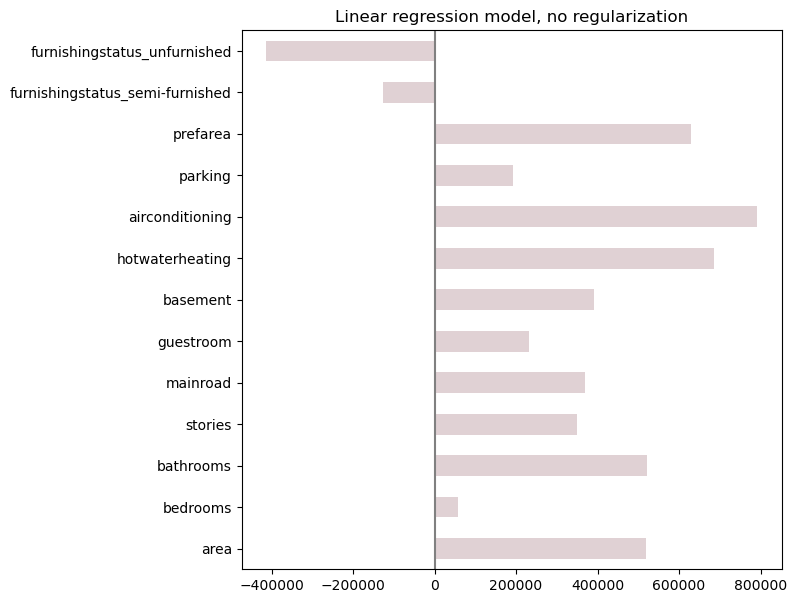

In [185]:
# Visualize the coefficients

coefs_1.plot(kind='barh', figsize=(9, 7), color="#e0d1d4")
plt.title('Linear regression model, no regularization')
plt.axvline(x=0, color='.5')
plt.subplots_adjust(left=.3)

#### Test the Model

We evaluate the trained model on the held-out test set by making predictions and calculating key performance metrics: R² (coefficient of determination), Adjusted R² (accounting for the number of predictors), MAE (Mean Absolute Error), and RMSE (Root Mean Squared Error). We also visualize the relationship between actual and predicted values to assess model accuracy.

In [186]:
# Predict on test data
y_pred_1 = final_model_1.predict(X_test_1)

# Calculate performance metrics
n_1 = len(y_test_1)
p_1 = X_test_1.shape[1]

r2_1 = metrics.r2_score(y_test_1, y_pred_1)
adjusted_r2_1 = 1 - (1 - r2_1) * (n_1 - 1) / (n_1 - p_1 - 1)

mae_1 = metrics.mean_absolute_error(y_test_1, y_pred_1)
mse_1 = metrics.mean_squared_error(y_test_1, y_pred_1)
rmse_1 = np.sqrt(mse_1)

print(
    f"Test R²: {r2_1:.3f}\n"
    f"Adjusted R²: {adjusted_r2_1:.3f}\n"
    f"MAE: {mae_1:.3f}\n"
    f"RMSE: {rmse_1:.3f}"
)

Test R²: 0.653
Adjusted R²: 0.605
MAE: 970043.404
RMSE: 1324506.960


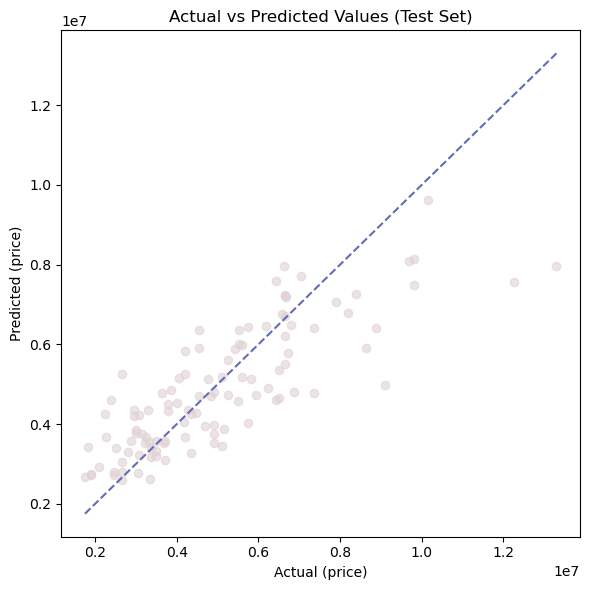

In [187]:
# Plot predicted vs actual

plt.figure(figsize=(6, 6))
plt.scatter(y_test_1, y_pred_1, color="#e0d1d4", alpha=0.6)
plt.plot(
    [y_test_1.min(), y_test_1.max()],
    [y_test_1.min(), y_test_1.max()],
    linestyle="--", 
    color='#636bb8'
)

plt.xlabel("Actual (price)")
plt.ylabel("Predicted (price)")
plt.title("Actual vs Predicted Values (Test Set)")
plt.tight_layout()
plt.show()

#### Analyse Residuals

We perform residual analysis to validate key linear regression assumptions. The residuals (actual - predicted values) are examined through three diagnostic plots: (1) Residuals vs Predicted to check for homoscedasticity and non-linear patterns, (2) Histogram of residuals to assess normality, and (3) Residuals vs Lagged Residuals to test for independence/autocorrelation.

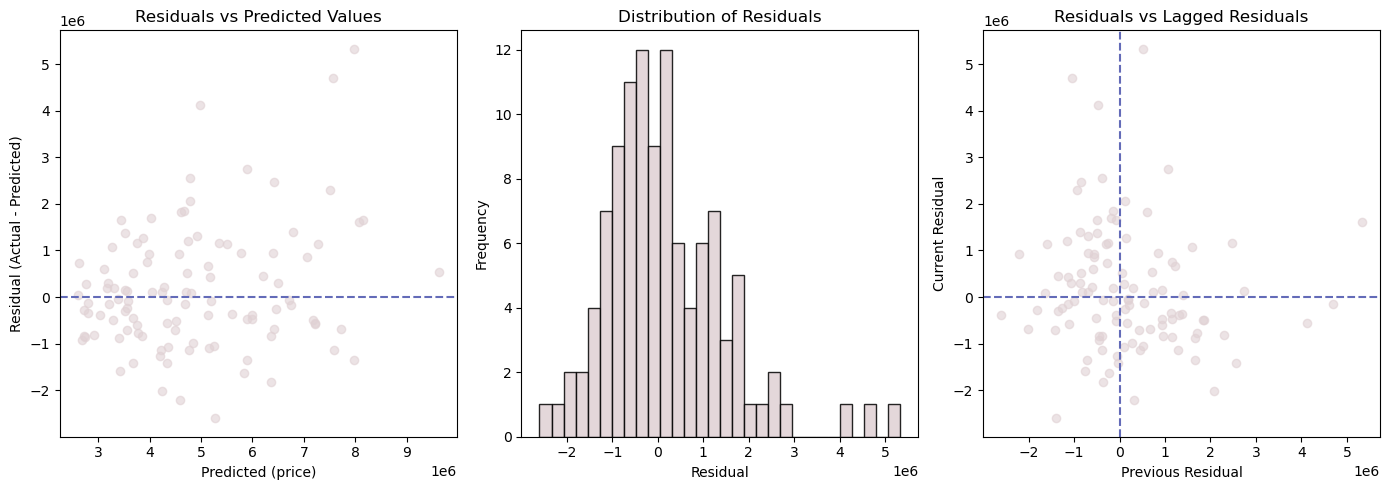

In [188]:
# Analyse and plot residuals
residuals_1 = y_test_1 - y_pred_1

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Residuals vs Predictions
axes[0].scatter(y_pred_1, residuals_1, color='#e0d1d4',alpha=0.6)
axes[0].axhline(0, color='#636bb8', linestyle='--')
axes[0].set_xlabel('Predicted (price)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Values')

# Histogram of Residuals
axes[1].hist(residuals_1, bins=30, color='#e0d1d4', edgecolor="black", alpha=0.85)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

# Residuals vs Lagged Residuals (independence check)
lagged_residuals_1 = residuals_1.shift(1)

axes[2].scatter(lagged_residuals_1, residuals_1, color='#e0d1d4', alpha=0.6)
axes[2].axhline(0, color='#636bb8', linestyle='--')
axes[2].axvline(0, color='#636bb8', linestyle='--')
axes[2].set_title('Residuals vs Lagged Residuals')
axes[2].set_xlabel('Previous Residual')
axes[2].set_ylabel('Current Residual')

plt.tight_layout()
plt.show()


### **Model 2: Log transformation on dependent variable**

This Multiple Linear Regression Model will focus on the most basic transformation of the independent variables and well as the log transformation of the dependent variable:
- Binary encoding + one-hot encoding + StandardScaler on numeric
- Log transformation on area and price
- All original features

#### Data Preparation

Building on Model 1's approach, we split the data, encode binary and categorical variables, and standardize numeric features. Additionally, we apply a log transformation to the 'area' feature to reduce right skewness, and crucially, we log-transform the target variable (price) to better satisfy normality assumptions and potentially improve model performance.

In [189]:
# Encode binary columns (yes/no --> 1/0)
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]

for d in (X_train_2, X_test_2):
    d[binary_cols] = d[binary_cols].replace({"yes": 1, "no": 0})

C:\Users\rothl\AppData\Local\Temp\ipykernel_45276\2867932313.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d[binary_cols] = d[binary_cols].replace({"yes": 1, "no": 0})
C:\Users\rothl\AppData\Local\Temp\ipykernel_45276\2867932313.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d[binary_cols] = d[binary_cols].replace({"yes": 1, "no": 0})


In [190]:
# Hot encoding nominal categorical (furniture)

ohe = OneHotEncoder(drop="first", sparse_output=False,handle_unknown='ignore')

# Fit on train only
train_ohe_2 = ohe.fit_transform(X_train_2[["furnishingstatus"]])
test_ohe_2  = ohe.transform(X_test_2[["furnishingstatus"]])

# Make DataFrames with same columns
ohe_cols_2 = ohe.get_feature_names_out(["furnishingstatus"])

train_ohe_df_2 = pd.DataFrame(train_ohe_2, columns=ohe_cols_2, index=X_train_2.index)
test_ohe_df_2  = pd.DataFrame(test_ohe_2,  columns=ohe_cols_2, index=X_test_2.index)

# Drop original col + concat encoded
X_train_2 = pd.concat([X_train_2.drop(columns=["furnishingstatus"]), train_ohe_df_2], axis=1)
X_test_2  = pd.concat([X_test_2.drop(columns=["furnishingstatus"]),  test_ohe_df_2], axis=1)

In [191]:
# Log transformation of area feature (to reduce right skewness)
X_train_2['area'] = np.log1p(X_train_2['area'])
X_test_2['area'] = np.log1p(X_test_2['area'])

print(f"Applied log transformation to 'area' feature")

Applied log transformation to 'area' feature


In [192]:
# Scale numerical independent variables

num_cols = ["area", "bedrooms", "bathrooms", "stories", "parking"]

scaler_2 = StandardScaler()

X_train_2[num_cols] = scaler_2.fit_transform(X_train_2[num_cols])  # fit on train
X_test_2[num_cols]  = scaler_2.transform(X_test_2[num_cols])       # transform test

In [193]:
# Log transformation of dependent variable
y_train_log_2 = np.log1p(y_train_2) 
y_test_log_2 = np.log1p(y_test_2)

print(f"Original y_train mean: {y_train_2.mean():,.2f}")
print(f"Transformed y_train_log mean: {y_train_log_2.mean():.2f}")

print(f"Original y_test mean: {y_test_2.mean():,.2f}")
print(f"Transformed y_test_log mean: {y_test_log_2.mean():.2f}")

Original y_train mean: 4,706,527.39
Transformed y_train_log mean: 15.30
Original y_test mean: 5,007,536.70
Transformed y_test_log mean: 15.33


In [194]:
y_train_log_2

46     15.833742
93     15.656060
335    15.181602
412    15.048071
471    14.917451
         ...    
71     15.725794
106    15.633587
270    15.283385
435    15.006398
102    15.639253
Name: price, Length: 436, dtype: float64

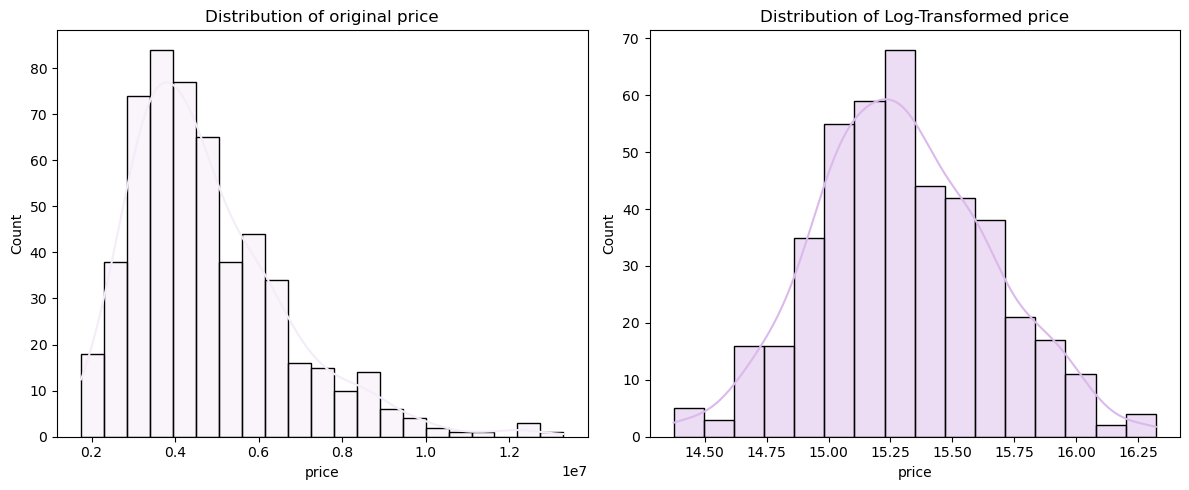

In [195]:
# Plot original target (price) vs log-transformed target

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color="#f4ecf85e")
plt.title('Distribution of original price')

plt.subplot(1, 2, 2)
sns.histplot(y_train_log_2, kde=True, color="#dbbaeb")
plt.title('Distribution of Log-Transformed price')

plt.tight_layout()
plt.show()

#### Train the Model

We fit a Linear Regression model on the log-transformed target variable. By modeling log(price) instead of price directly, we aim to capture multiplicative relationships and reduce the impact of extreme values. We examine the learned coefficients, which now represent the proportional change in price for unit changes in each feature.

In [196]:
final_model_2 = LinearRegression()
final_model_2.fit(X_train_2, y_train_log_2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [197]:
coefs_2 = pd.Series(final_model_2.coef_, index=X_train_2.columns)
coefs_2

area                               0.117738
bedrooms                           0.015212
bathrooms                          0.088154
stories                            0.070872
mainroad                           0.088888
guestroom                          0.036195
basement                           0.104123
hotwaterheating                    0.131848
airconditioning                    0.145646
parking                            0.028276
prefarea                           0.133227
furnishingstatus_semi-furnished   -0.005022
furnishingstatus_unfurnished      -0.114758
dtype: float64

In [198]:
print(f"Intercept: {final_model_2.intercept_}")

Intercept: 15.136734767157318


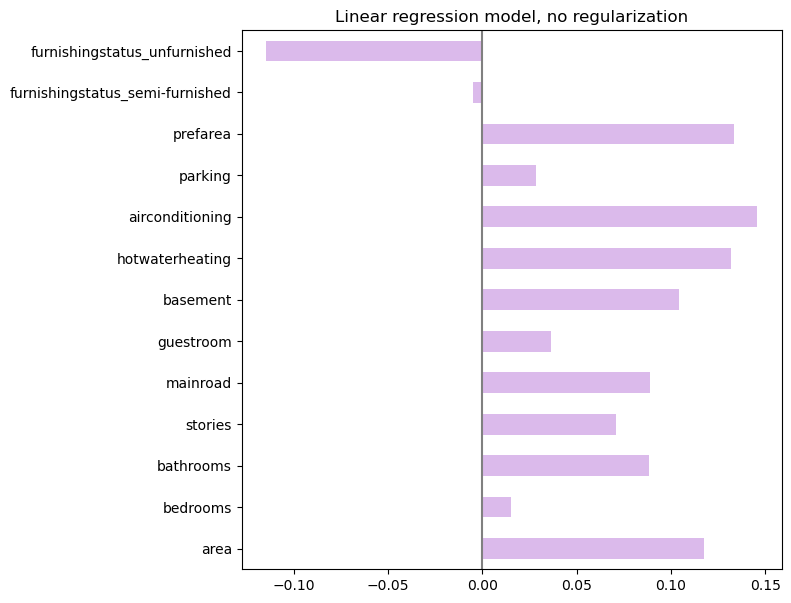

In [199]:
# Plot the coefficients

coefs_2.plot(kind='barh', figsize=(9, 7), color="#dbbaeb" )
plt.title('Linear regression model, no regularization')
plt.axvline(x=0, color='.5')
plt.subplots_adjust(left=.3)

#### Test the Model

We generate predictions on the test set and apply inverse log transformation (expm1) to convert predictions back to the original price scale. Performance metrics (R², Adjusted R², MAE, RMSE) are calculated on the original scale to enable direct comparison with Model 1 and assess whether log transformation improved predictive accuracy.

In [200]:
# Predict on test data
y_pred_2 = final_model_2.predict(X_test_2)
y_pred_original_scale_2 = np.expm1(y_pred_2)

# Calculate performance metrics
n_2 = len(y_test_2)
p_2 = X_test_2.shape[1]

r2_2 = metrics.r2_score(y_test_2, y_pred_original_scale_2)
adjusted_r2_2 = 1 - (1 - r2_2) * (n_2 - 1) / (n_2 - p_2 - 1)

mae_2 = metrics.mean_absolute_error(y_test_2, y_pred_original_scale_2)
mse_2 = metrics.mean_squared_error(y_test_2, y_pred_original_scale_2)
rmse_2 = np.sqrt(mse_2)

print(
    f"Test R²: {r2_2:.3f}\n"
    f"Adjusted R²: {adjusted_r2_2:.3f}\n"
    f"MAE: {mae_2:.3f}\n"
    f"RMSE: {rmse_2:.3f}"
)

Test R²: 0.659
Adjusted R²: 0.612
MAE: 969727.788
RMSE: 1313681.208


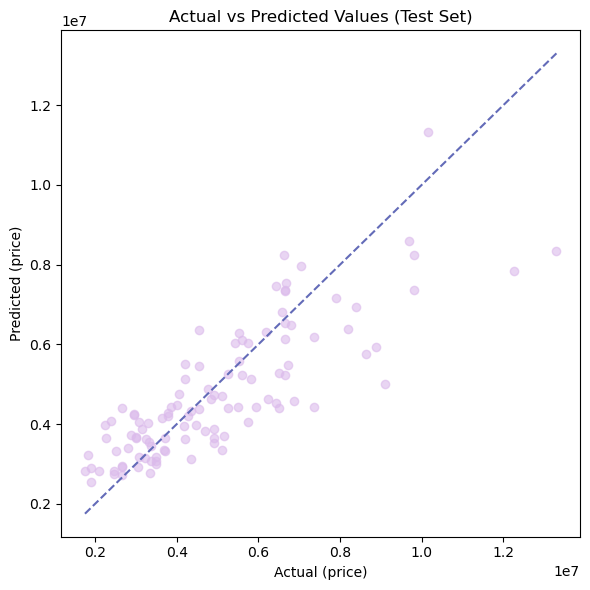

In [201]:
# Plot actual vs predicted 
plt.figure(figsize=(6, 6))
plt.scatter(y_test_2, y_pred_original_scale_2, color="#dbbaeb", alpha=0.6)
plt.plot(
    [y_test_2.min(), y_test_2.max()],
    [y_test_2.min(), y_test_2.max()],
    linestyle="--",
    color='#636bb8'

)

plt.xlabel("Actual (price)")
plt.ylabel("Predicted (price)")
plt.title("Actual vs Predicted Values (Test Set)")
plt.tight_layout()
plt.show()

#### Analyse Residuals

We conduct residual diagnostics on the original price scale to assess whether log transformation improved model assumptions. The three diagnostic plots help us evaluate if residuals show improved homoscedasticity, better approximate a normal distribution, and exhibit independence compared to Model 1.

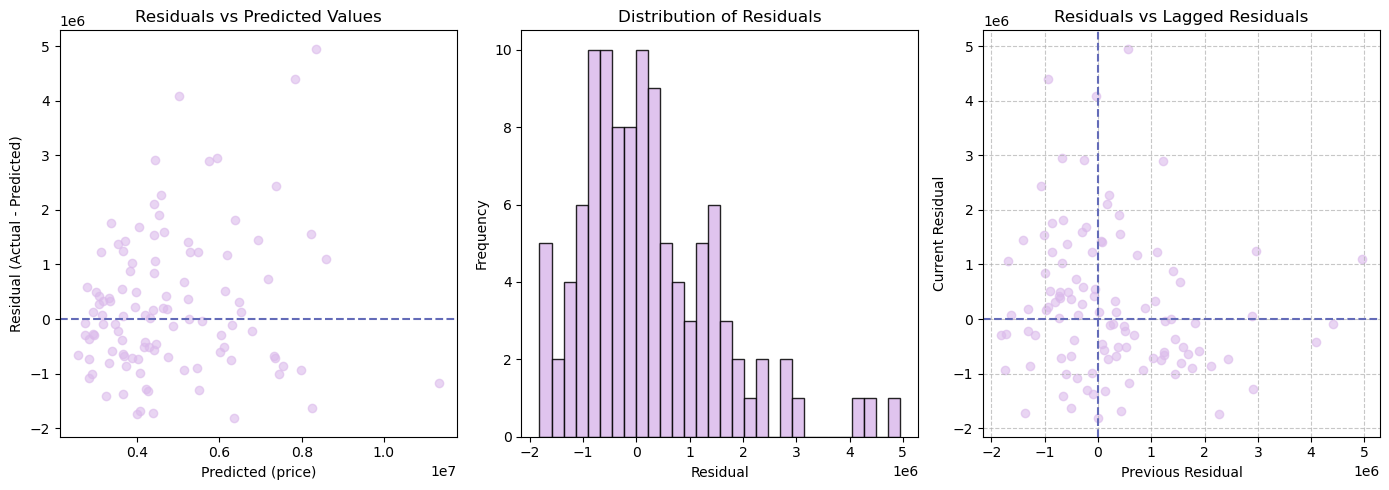

In [202]:
# Analyse and plot residuals

residuals_2 = y_test_2 - y_pred_original_scale_2

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Residuals vs Predictions
axes[0].scatter(y_pred_original_scale_2, residuals_2,color="#dbbaeb", alpha=0.6)
axes[0].axhline(0, color='#636bb8', linestyle='--')
axes[0].set_xlabel('Predicted (price)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Values')

# Histogram of Residuals
axes[1].hist(residuals_2, bins=30, edgecolor="black",color="#dbbaeb", alpha=0.85)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

# Residuals vs Lagged Residuals (independence check)
lagged_residuals_2 = residuals_2.shift(1)

axes[2].scatter(lagged_residuals_2, residuals_2, color="#dbbaeb", alpha=0.6)
axes[2].axhline(0, color='#636bb8', linestyle='--')
axes[2].axvline(0, color='#636bb8', linestyle='--')
axes[2].set_title('Residuals vs Lagged Residuals')
axes[2].set_xlabel('Previous Residual')
axes[2].set_ylabel('Current Residual')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### **Model 3: Log + Feature Selection**

This Multiple Linear Regression Model will focus on the most basic transformation of the independent variables, the log transformation of the dependent variable, and using LassoCV with an aggressive threshold to drop features:
- Binary encoding + one-hot encoding + StandardScaler on numerics
- Log transformation on price
- LassoCV with aggressive threshold to drop weak features

#### Data Preparation

We follow the same preprocessing as Model 2 (split, encode, scale, log-transform target), but add an additional feature selection step. Using LassoCV with 10-fold cross-validation, we identify the optimal regularization strength and apply an aggressive threshold (0.4 * mean of absolute coefficients) to select only the most predictive features, reducing model complexity and potentially preventing overfitting.

In [203]:
# Encode binary columns (yes/no --> 1/0)
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]

for d in (X_train_3, X_test_3):
    d[binary_cols] = d[binary_cols].replace({"yes": 1, "no": 0})

C:\Users\rothl\AppData\Local\Temp\ipykernel_45276\1555562343.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d[binary_cols] = d[binary_cols].replace({"yes": 1, "no": 0})
C:\Users\rothl\AppData\Local\Temp\ipykernel_45276\1555562343.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d[binary_cols] = d[binary_cols].replace({"yes": 1, "no": 0})


In [204]:
# Hot encoding nominal categorical (furniture)

ohe = OneHotEncoder(drop="first", sparse_output=False,handle_unknown='ignore')

# fit on train only
train_ohe_3 = ohe.fit_transform(X_train_3[["furnishingstatus"]])
test_ohe_3  = ohe.transform(X_test_3[["furnishingstatus"]])

# make DataFrames with same columns
ohe_cols_3 = ohe.get_feature_names_out(["furnishingstatus"])

train_ohe_df_3 = pd.DataFrame(train_ohe_3, columns=ohe_cols_3, index=X_train_3.index)
test_ohe_df_3  = pd.DataFrame(test_ohe_3,  columns=ohe_cols_3, index=X_test_3.index)

# drop original col + concat encoded
X_train_3 = pd.concat([X_train_3.drop(columns=["furnishingstatus"]), train_ohe_df_3], axis=1)
X_test_3  = pd.concat([X_test_3.drop(columns=["furnishingstatus"]),  test_ohe_df_3], axis=1)

In [205]:
# Log transformation of area feature (to reduce right skewness)
X_train_3['area'] = np.log1p(X_train_3['area'])
X_test_3['area'] = np.log1p(X_test_3['area'])

print(f"Applied log transformation to 'area' feature")

Applied log transformation to 'area' feature


In [206]:
# Scale numerical independent variables

num_cols = ["area", "bedrooms", "bathrooms", "stories", "parking"]

scaler_3 = StandardScaler()

X_train_3[num_cols] = scaler_3.fit_transform(X_train_3[num_cols])  # fit on train
X_test_3[num_cols]  = scaler_3.transform(X_test_3[num_cols])       # transform test

In [207]:
# Log transformation of dependent variable
y_train_log_3 = np.log1p(y_train_3) 
y_test_log_3 = np.log1p(y_test_3)

print(f"Original y_train mean: {y_train_3.mean():,.2f}")
print(f"Transformed y_train_log mean: {y_train_log_3.mean():.2f}")

print(f"Original y_test mean: {y_test_3.mean():,.2f}")
print(f"Transformed y_test_log mean: {y_test_log_3.mean():.2f}")

Original y_train mean: 4,706,527.39
Transformed y_train_log mean: 15.30
Original y_test mean: 5,007,536.70
Transformed y_test_log mean: 15.33


In [208]:
# Now fit Lasso on log-transformed target
lasso_selector = LassoCV(cv=10, random_state=42, max_iter=10000)
lasso_selector.fit(X_train_3.values, y_train_log_3)  # Use log-transformed y

print(f"Selected alpha: {lasso_selector.alpha_}")
print(f"Non-zero coefficients: {np.sum(lasso_selector.coef_ != 0)}")

# Use 0.4 * mean as threshold for feature selection
selector = SelectFromModel(estimator=lasso_selector, prefit=True,threshold="0.4 * mean")

# Transform data
X_train_selected_np = selector.transform(X_train_3.values)
X_test_selected_np = selector.transform(X_test_3.values)

all_feature_names = X_train_3.columns.tolist()  
selected_mask = selector.get_support()

selected_feature_names_after_lasso = [name for name, keep in zip(all_feature_names, selected_mask) if keep]

X_train_selected_3 = pd.DataFrame(X_train_selected_np, columns=selected_feature_names_after_lasso, index=X_train_3.index)
X_test_selected_3 = pd.DataFrame(X_test_selected_np, columns=selected_feature_names_after_lasso, index=X_test_3.index)

print(f"Selected {len(selected_feature_names_after_lasso)} features")
print(selected_feature_names_after_lasso)

Selected alpha: 0.0007171638040325565
Non-zero coefficients: 12
Selected 10 features
['area', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus_unfurnished']


#### Train the Model

We train a standard Linear Regression model using only the features selected by LassoCV, fitting on the log-transformed target. This parsimonious model includes fewer predictors than Models 1 and 2, potentially offering better interpretability and generalization. We examine the coefficients to understand which features were deemed most important and their relative impact on housing prices.

In [209]:
# Train the model

final_model_3 = LinearRegression()
final_model_3.fit(X_train_selected_3, y_train_log_3)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [210]:
# Inspect the coefficients

coefs_3 = pd.Series(final_model_3.coef_, index=selected_feature_names_after_lasso)
coefs_3

area                            0.126931
bathrooms                       0.095379
stories                         0.074427
mainroad                        0.091576
guestroom                       0.029023
basement                        0.109012
hotwaterheating                 0.141772
airconditioning                 0.153578
prefarea                        0.136658
furnishingstatus_unfurnished   -0.118193
dtype: float64

In [211]:
print(f"Intercept: {final_model_3.intercept_}")

Intercept: 15.129134699108851


In [212]:
# Show coefficients and their selection Status

coef_df_3 = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lasso_selector.coef_,
    'Abs_Coefficient': np.abs(lasso_selector.coef_),
    'Selected': selected_mask
})

coef_df_3 = coef_df_3.sort_values('Abs_Coefficient', ascending=False)
print(coef_df_3)

                            Feature  Coefficient  Abs_Coefficient  Selected
8                   airconditioning     0.142529         0.142529      True
10                         prefarea     0.130634         0.130634      True
0                              area     0.118509         0.118509      True
7                   hotwaterheating     0.115488         0.115488      True
12     furnishingstatus_unfurnished    -0.109663         0.109663      True
6                          basement     0.103564         0.103564      True
2                         bathrooms     0.088105         0.088105      True
4                          mainroad     0.084301         0.084301      True
3                           stories     0.071222         0.071222      True
5                         guestroom     0.032937         0.032937      True
9                           parking     0.028593         0.028593     False
1                          bedrooms     0.014976         0.014976     False
11  furnishi

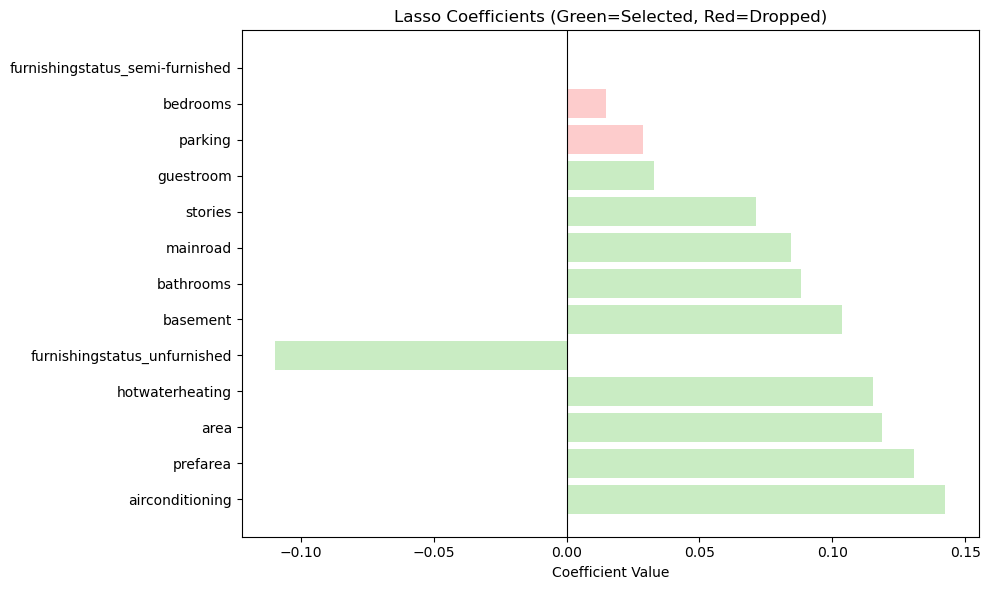

In [213]:
# Visualize coefficients

plt.figure(figsize=(10, 6))
colors = ["#c9ecc3" if x else "#fdcccc" for x in coef_df_3['Selected']]
plt.barh(coef_df_3['Feature'], coef_df_3['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Lasso Coefficients (Green=Selected, Red=Dropped)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

#### Test the Model

We evaluate the feature-selected model on the test set, transforming predictions back to the original price scale. Performance metrics are calculated to determine whether feature selection improved model performance through reduced variance (overfitting) despite using fewer predictors. The Adjusted R² is particularly relevant here as it accounts for the reduced model complexity.

In [214]:
# Predict on test data

y_pred_3 = final_model_3.predict(X_test_selected_3)
y_pred_original_scale_3 = np.expm1(y_pred_3)

# Calculate performance metrics
n_3 = len(y_test_3)
p_3 = X_test_selected_3.shape[1]

r2_3 = metrics.r2_score(y_test_3, y_pred_original_scale_3)
adjusted_r2_3 = 1 - (1 - r2_3) * (n_3 - 1) / (n_3 - p_3 - 1)

mae_3 = metrics.mean_absolute_error(y_test_3, y_pred_original_scale_3)
mse_3 = metrics.mean_squared_error(y_test_3, y_pred_original_scale_3)
rmse_3 = np.sqrt(mse_3)

print(
    f"Test R²: {r2_3:.3f}\n"
    f"Adjusted R²: {adjusted_r2_3:.3f}\n"
    f"MAE: {mae_3:.3f}\n"
    f"RMSE: {rmse_3:.3f}"
)

Test R²: 0.634
Adjusted R²: 0.597
MAE: 1001844.641
RMSE: 1359475.110


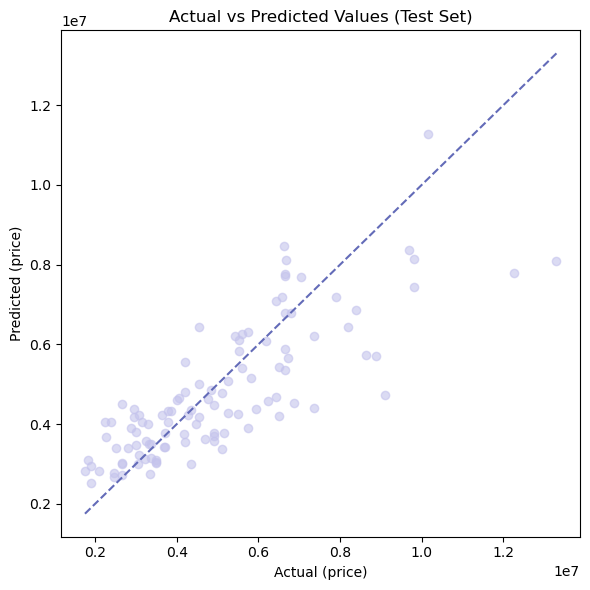

In [215]:
# Plot actual vs predicted

plt.figure(figsize=(6, 6))
plt.scatter(y_test_3, y_pred_original_scale_3, color='#c4c3ec', alpha=0.6)
plt.plot(
    [y_test_3.min(), y_test_3.max()],
    [y_test_3.min(), y_test_3.max()],
    linestyle="--",
    color='#636bb8'
)

plt.xlabel("Actual (price)")
plt.ylabel("Predicted (price)")
plt.title("Actual vs Predicted Values (Test Set)")
plt.tight_layout()
plt.show()

#### Analyse Residuals

We perform the same residual diagnostics as in previous models to validate regression assumptions. This analysis helps determine whether the combination of log transformation and feature selection produced residuals that better satisfy the assumptions of linearity, homoscedasticity, normality, and independence compared to Models 1 and 2.

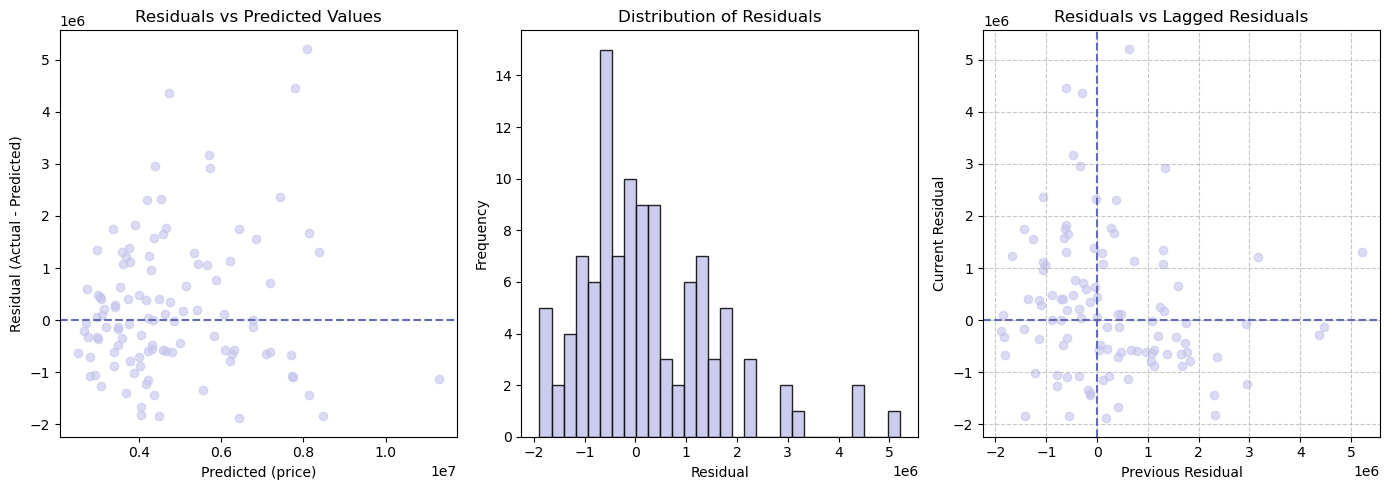

In [216]:
# Analyse and plot residuals

residuals_3 = y_test_3 - y_pred_original_scale_3

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Residuals vs Predictions
axes[0].scatter(y_pred_original_scale_3, residuals_3, color='#c4c3ec',alpha=0.6)
axes[0].axhline(0, color='#636bb8', linestyle='--')
axes[0].set_xlabel('Predicted (price)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Values')

# Histogram of Residuals
axes[1].hist(residuals_3, bins=30, edgecolor="black", color='#c4c3ec', alpha=0.85)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

# Residuals vs Lagged Residuals (independence check)
lagged_residuals_3 = residuals_3.shift(1)

axes[2].scatter(lagged_residuals_3, residuals_3, color='#c4c3ec', alpha=0.6)
axes[2].axhline(0, color='#636bb8', linestyle='--')
axes[2].axvline(0, color='#636bb8', linestyle='--')
axes[2].set_title('Residuals vs Lagged Residuals')
axes[2].set_xlabel('Previous Residual')
axes[2].set_ylabel('Current Residual')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### **Model 4: Log + Outlier Removal**

This Multiple Linear Regression Model will focus on the most basic transformation of the independent variables, the log transformation of the dependent variable, and using LassoCV with an aggressive threshold to drop features:
- Binary encoding + one-hot encoding + StandardScaler on numerics
- Log transformation on price
- Remove outliers using IQR on log(price) in training data only



#### Data Preparation

In [217]:
# Make copies of the shared split for Model 4
X_train_4 = X_train.copy()
X_test_4 = X_test.copy()
y_train_4 = y_train.copy()
y_test_4 = y_test.copy()
X_train_4.shape, X_test_4.shape

((436, 12), (109, 12))

In [218]:
# Encode binary columns (yes/no --> 1/0)
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]

for d in (X_train_4, X_test_4):
    d[binary_cols] = d[binary_cols].replace({"yes": 1, "no": 0})

C:\Users\rothl\AppData\Local\Temp\ipykernel_45276\3578481719.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d[binary_cols] = d[binary_cols].replace({"yes": 1, "no": 0})
C:\Users\rothl\AppData\Local\Temp\ipykernel_45276\3578481719.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d[binary_cols] = d[binary_cols].replace({"yes": 1, "no": 0})


In [219]:
# Hot encoding nominal categorical (furniture)

ohe = OneHotEncoder(drop="first", sparse_output=False,handle_unknown='ignore')

# fit on train only
train_ohe_4 = ohe.fit_transform(X_train_4[["furnishingstatus"]])
test_ohe_4  = ohe.transform(X_test_4[["furnishingstatus"]])

# make DataFrames with same columns
ohe_cols_4 = ohe.get_feature_names_out(["furnishingstatus"])

train_ohe_df_4 = pd.DataFrame(train_ohe_4, columns=ohe_cols_4, index=X_train_4.index)
test_ohe_df_4  = pd.DataFrame(test_ohe_4,  columns=ohe_cols_4, index=X_test_4.index)

# drop original col + concat encoded
X_train_4 = pd.concat([X_train_4.drop(columns=["furnishingstatus"]), train_ohe_df_4], axis=1)
X_test_4  = pd.concat([X_test_4.drop(columns=["furnishingstatus"]),  test_ohe_df_4], axis=1)

In [220]:
# Log transformation of area feature (to reduce right skewness)
X_train_4['area'] = np.log1p(X_train_4['area'])
X_test_4['area'] = np.log1p(X_test_4['area'])

print(f"Applied log transformation to 'area' feature")

Applied log transformation to 'area' feature


In [221]:
# Scale numerical independent variables

num_cols = ["area", "bedrooms", "bathrooms", "stories", "parking"]

scaler_4 = StandardScaler()

X_train_4[num_cols] = scaler_4.fit_transform(X_train_4[num_cols])  # fit on train
X_test_4[num_cols]  = scaler_4.transform(X_test_4[num_cols])       # transform test

In [222]:
# Log transformation of dependent variable
y_train_log_4 = np.log1p(y_train_4) 
y_test_log_4 = np.log1p(y_test_4)

print(f"Original y_train mean: {y_train_4.mean():,.2f}")
print(f"Transformed y_train_log mean: {y_train_log_4.mean():.2f}")

print(f"Original y_test mean: {y_test_4.mean():,.2f}")
print(f"Transformed y_test_log mean: {y_test_log_4.mean():.2f}")

Original y_train mean: 4,706,527.39
Transformed y_train_log mean: 15.30
Original y_test mean: 5,007,536.70
Transformed y_test_log mean: 15.33


In [223]:
# Remove outliers in training set only (IQR on log(price))
q1 = y_train_log_4.quantile(0.25)
q3 = y_train_log_4.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

train_mask = y_train_log_4.between(lower, upper)

# Apply mask to training features and targets
X_train_4 = X_train_4.loc[train_mask].copy()
y_train_4 = y_train_4.loc[train_mask].copy()
y_train_log_4 = y_train_log_4.loc[train_mask].copy()

print(f"Train rows kept after IQR filter: {train_mask.sum()} / {len(train_mask)}")

Train rows kept after IQR filter: 433 / 436


#### Train the Model

In [224]:
final_model_4 = LinearRegression()
final_model_4.fit(X_train_4, y_train_log_4)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [225]:
coefs_4 = pd.Series(final_model_4.coef_, index=X_train_4.columns)
coefs_4

area                               0.117254
bedrooms                           0.012329
bathrooms                          0.090374
stories                            0.071706
mainroad                           0.090120
guestroom                          0.032587
basement                           0.100279
hotwaterheating                    0.133807
airconditioning                    0.141735
parking                            0.024829
prefarea                           0.135203
furnishingstatus_semi-furnished    0.001980
furnishingstatus_unfurnished      -0.109461
dtype: float64

In [226]:
print(f"Intercept: {final_model_4.intercept_}")

Intercept: 15.131534596260284


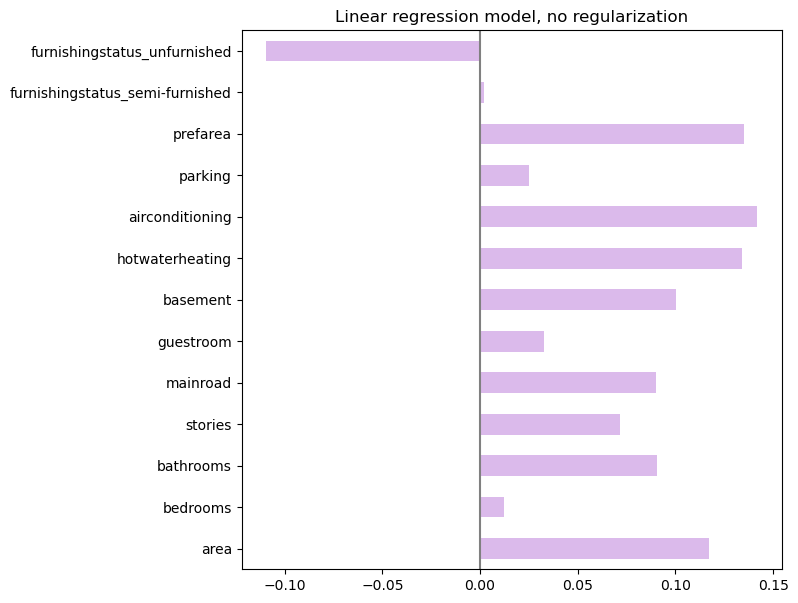

In [227]:
# Plot the coefficients

coefs_4.plot(kind='barh', figsize=(9, 7), color="#dbbaeb" )
plt.title('Linear regression model, no regularization')
plt.axvline(x=0, color='.5')
plt.subplots_adjust(left=.3)

#### Test the Model

In [228]:
# Predict on test data

y_pred_4 = final_model_4.predict(X_test_4)
y_pred_original_scale_4 = np.expm1(y_pred_4)

# Calculate performance metrics
n_4 = len(y_test_4)
p_4 = X_test_4.shape[1]

r2_4 = metrics.r2_score(y_test_4, y_pred_original_scale_4)
adjusted_r2_4 = 1 - (1 - r2_4) * (n_4 - 1) / (n_4 - p_4 - 1)

mae_4 = metrics.mean_absolute_error(y_test_4, y_pred_original_scale_4)
mse_4 = metrics.mean_squared_error(y_test_4, y_pred_original_scale_4)
rmse_4 = np.sqrt(mse_4)

print(
    f"Test R²: {r2_4:.3f}\n"
    f"Adjusted R²: {adjusted_r2_4:.3f}\n"
    f"MAE: {mae_4:.3f}\n"
    f"RMSE: {rmse_4:.3f}"
)

Test R²: 0.653
Adjusted R²: 0.605
MAE: 974710.919
RMSE: 1324699.582


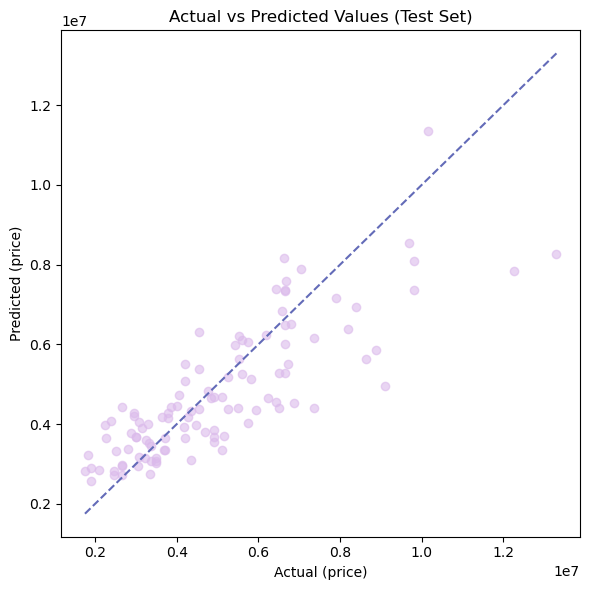

In [229]:
# Plot actual vs prediction

plt.figure(figsize=(6, 6))
plt.scatter(y_test_4, y_pred_original_scale_4, color="#dbbaeb", alpha=0.6)
plt.plot(
    [y_test_4.min(), y_test_4.max()],
    [y_test_4.min(), y_test_4.max()],
    linestyle="--",
    color='#636bb8'

)

plt.xlabel("Actual (price)")
plt.ylabel("Predicted (price)")
plt.title("Actual vs Predicted Values (Test Set)")
plt.tight_layout()
plt.show()

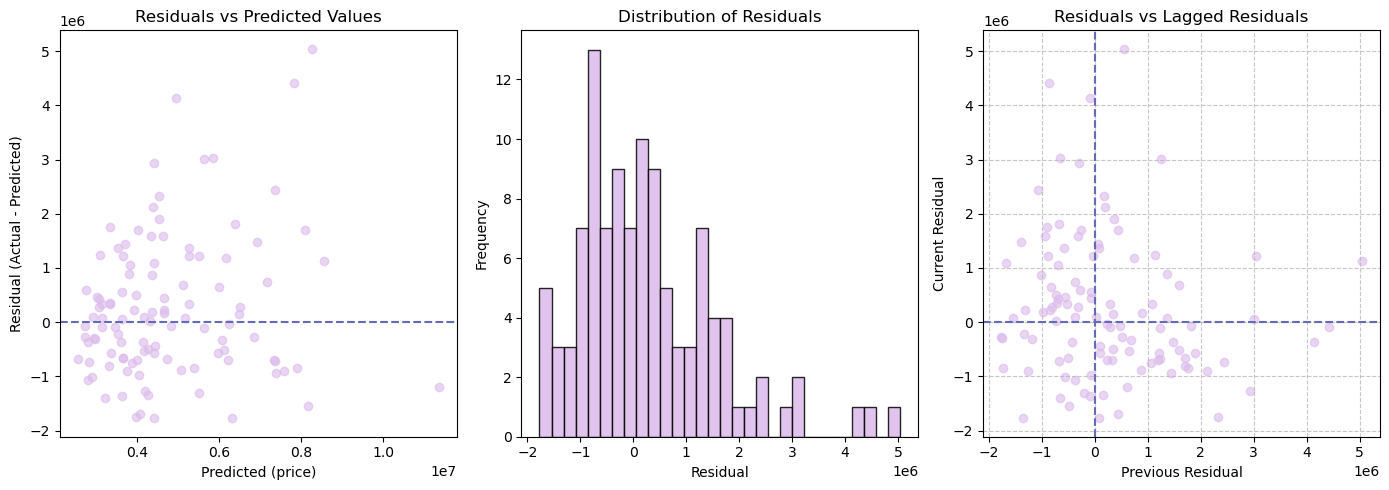

In [230]:
# Analyse and plot residuals
residuals_4 = y_test_4 - y_pred_original_scale_4

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Residuals vs Predictions
axes[0].scatter(y_pred_original_scale_4, residuals_4,color="#dbbaeb", alpha=0.6)
axes[0].axhline(0, color='#636bb8', linestyle='--')
axes[0].set_xlabel('Predicted (price)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Values')

# Histogram of Residuals
axes[1].hist(residuals_4, bins=30, edgecolor="black",color="#dbbaeb", alpha=0.85)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

# Residuals vs Lagged Residuals (independence check)
lagged_residuals_4 = residuals_4.shift(1)

axes[2].scatter(lagged_residuals_4, residuals_4, color="#dbbaeb", alpha=0.6)
axes[2].axhline(0, color='#636bb8', linestyle='--')
axes[2].axvline(0, color='#636bb8', linestyle='--')
axes[2].set_title('Residuals vs Lagged Residuals')
axes[2].set_xlabel('Previous Residual')
axes[2].set_ylabel('Current Residual')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **Model 5: K-Fold CV (Model 2 preprocessing)**

While Models 1-4 relied on a single 80/20 train-test split, which can produce results highly dependent on how the data is randomly divided, K-Fold Cross-Validation provides a more robust evaluation by partitioning the entire dataset into 5 equal folds, ensuring every data point is used for both training and validation.

By replicating Model 2's preprocessing (log transformation and standardization) within each fold without data leakage, K-Fold CV gives us confidence that our performance metrics are stable and not artifacts of a particular train-test split

#### Data Preparation

In [231]:
# Define our target variable (y)
TARGET_5 = "price"

X_cv_5 = df.drop(columns=[TARGET]).copy()
y_cv_5 = df[TARGET]

In [232]:
# Encode binary columns (yes/no --> 1/0)
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
X_cv_5[binary_cols] = X_cv_5[binary_cols].replace({"yes": 1, "no": 0})

C:\Users\rothl\AppData\Local\Temp\ipykernel_45276\1574917809.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_cv_5[binary_cols] = X_cv_5[binary_cols].replace({"yes": 1, "no": 0})


In [233]:
# Log transform area
X_cv_5["area"] = np.log1p(X_cv_5["area"])

In [234]:
# Manually iterate through folds
num_cols = ["area", "bedrooms", "bathrooms", "stories", "parking"]
cat_cols = ["furnishingstatus"]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

#### Train and Test the Model

In [235]:
r2_scores_5, mae_scores_5, rmse_scores_5 = [], [], []
all_y_test_5, all_y_pred_5 = [], []

for train_idx, test_idx in kf.split(X_cv_5):
    X_train, X_test = X_cv_5.iloc[train_idx].copy(), X_cv_5.iloc[test_idx].copy()
    y_train, y_test = y_cv_5.iloc[train_idx], y_cv_5.iloc[test_idx]
    
    # One-hot encode categorical on train, apply to test
    ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown='ignore')
    train_ohe = ohe.fit_transform(X_train[cat_cols])
    test_ohe = ohe.transform(X_test[cat_cols])
    
    ohe_cols = ohe.get_feature_names_out(cat_cols)
    train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_cols, index=X_train.index)
    test_ohe_df = pd.DataFrame(test_ohe, columns=ohe_cols, index=X_test.index)
    
    X_train = pd.concat([X_train.drop(columns=cat_cols), train_ohe_df], axis=1)
    X_test = pd.concat([X_test.drop(columns=cat_cols), test_ohe_df], axis=1)
    
    # Scale on train, transform test
    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])
    
    # Train model on log-transformed target
    model = LinearRegression()
    model.fit(X_train, np.log1p(y_train))
    
    # Predict and inverse transform
    y_pred = np.expm1(model.predict(X_test))

    # Collect all test values and predictions for visualization
    all_y_test_5.extend(y_test.tolist())
    all_y_pred_5.extend(y_pred.tolist())

    # Calculate metrics
    r2_scores_5.append(metrics.r2_score(y_test, y_pred))
    mae_scores_5.append(metrics.mean_absolute_error(y_test, y_pred))
    rmse_scores_5.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


In [236]:
len(all_y_test_5)

545

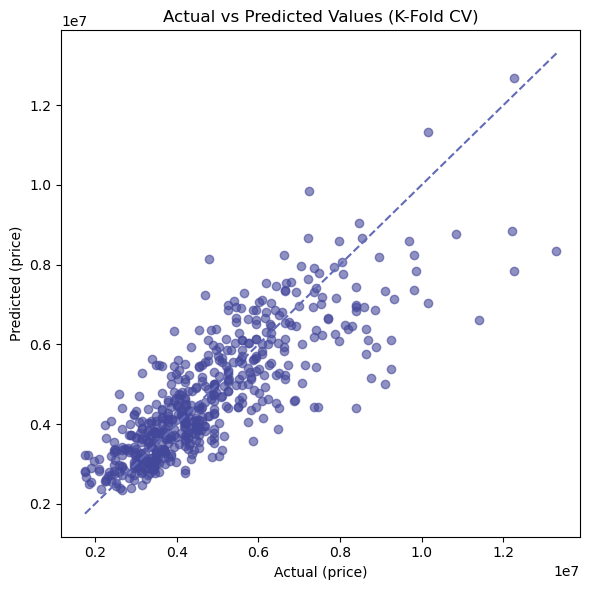

In [237]:
# Visualize predictions vs actuals

plt.figure(figsize=(6, 6))
plt.scatter(all_y_test_5, all_y_pred_5, color="#44489a", alpha=0.6)
plt.plot(
    [min(all_y_test_5), max(all_y_test_5)],
    [min(all_y_test_5), max(all_y_test_5)],
    linestyle="--", 
    color='#636bb8'
)

plt.xlabel("Actual (price)")
plt.ylabel("Predicted (price)")
plt.title("Actual vs Predicted Values (K-Fold CV)")
plt.tight_layout()
plt.show()

In [238]:
# Summary metrics

n_5 = len(df)
p_5 = 13
r2_cv_5 = np.mean(r2_scores_5)
adjusted_r2_cv_5 = 1 - (1 - r2_cv_5) * (n_5 - 1) / (n_5 - p_5 - 1)
mae_cv_5 = np.mean(mae_scores_5)
rmse_cv_5 = np.mean(rmse_scores_5)

print(f"R²: {r2_cv_5:.3f}")
print(f"Adjusted R²: {adjusted_r2_cv_5:.3f}")
print(f"MAE: {mae_cv_5:.3f}")
print(f"RMSE: {rmse_cv_5:.3f}")

R²: 0.661
Adjusted R²: 0.653
MAE: 767994.667
RMSE: 1052051.372


#### Residual Analysis

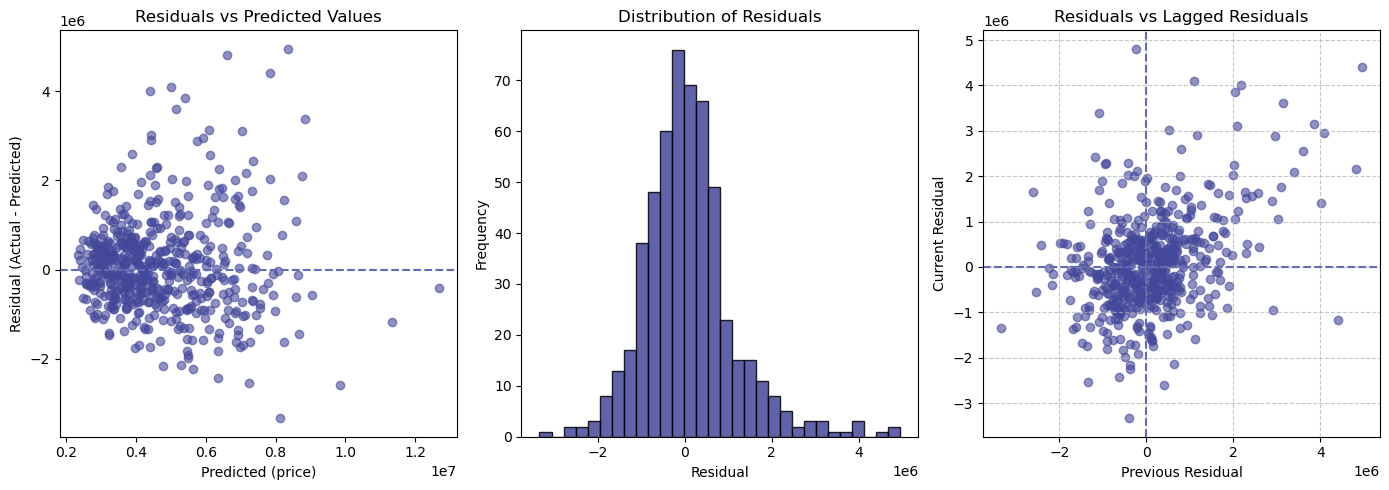

In [239]:
# Analyse and plot residuals

residuals_5 = pd.Series(all_y_test_5) - pd.Series(all_y_pred_5)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Residuals vs Predictions
axes[0].scatter(all_y_pred_5, residuals_5, color="#44489a", alpha=0.6)
axes[0].axhline(0, color='#636bb8', linestyle='--')
axes[0].set_xlabel('Predicted (price)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Values')

# Histogram of Residuals
axes[1].hist(residuals_5, bins=30, edgecolor="black", color="#44489a", alpha=0.85)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

# Residuals vs Lagged Residuals (independence check)
lagged_residuals_5 = residuals_5.shift(1)

axes[2].scatter(lagged_residuals_5, residuals_5, color="#44489a", alpha=0.6)
axes[2].axhline(0, color='#636bb8', linestyle='--')
axes[2].axvline(0, color='#636bb8', linestyle='--')
axes[2].set_title('Residuals vs Lagged Residuals')
axes[2].set_xlabel('Previous Residual')
axes[2].set_ylabel('Current Residual')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **Model Comparison & Interpretation**

#### Model Comparison

In [240]:
comparison_df = pd.DataFrame({
    'Model': ['1: Baseline', '2: Log Price', '3: Log + Lasso', '4: Outlier Removal', '5: K-Fold CV'],
    'R² Score': [r2_1, r2_2, r2_3, r2_4, r2_cv_5],
    'Adjusted R²': [adjusted_r2_1, adjusted_r2_2, adjusted_r2_3, adjusted_r2_4, adjusted_r2_cv_5],
    'MAE': [mae_1, mae_2, mae_3, mae_4, mae_cv_5],
    'RMSE': [rmse_1, rmse_2, rmse_3, rmse_4, rmse_cv_5],
    'Features Used': [p_1, p_2, p_3, p_4, p_5]
})

comparison_df

,Model,R² Score,Adjusted R²,MAE,RMSE,Features Used
0,1: Baseline,0.652924,0.605430,9.700434e+05,1.324507e+06,13
1,2: Log Price,0.658575,0.611853,9.697278e+05,1.313681e+06,13
2,3: Log + Lasso,0.634356,0.597046,1.001845e+06,1.359475e+06,10
3,4: Outlier Removal,0.652823,0.605315,9.747109e+05,1.324700e+06,13
4,5: K-Fold CV,0.661359,0.653068,7.679947e+05,1.052051e+06,13


Looking across all five models, Model 5 (K-Fold Cross-Validation) emerges as the clear winner. With an R² score of 0.661 and an Adjusted R² of 0.653, it explains approximately 66% of the variance in house prices. Additionally, Model 5 achieves the lowest prediction error metrics (MAE and RMSE). This is because the K-Fold validation approach is more robust than single train-test splits since it leverages all 545 data points for both training and validation.

#### Business Implication

Our project successfully developed a multiple regression model capable of predicting house prices based on structural and contextual housing attributes. Using Model 5 (K-Fold Cross-Validation with log transformations), we achieved an R² score of 0.661, meaning our model explains 66% of the variance in house prices with a Mean Absolute Error of approximately USD 768,000 a reasonable margin for the USD 1.75M to USD 13.3M price range in our dataset.

The analysis confirms that all 12 housing attributes contribute meaningfully to price prediction. The most influential features are property area (requiring log transformation due to right-skewness), location quality (main road access, preferred area status), and amenities (bathrooms, bedrooms, air conditioning, hot water heating). 

The model provides reliable ballpark price estimates for initial market assessments, useful for buyers, sellers, and real estate professionals for market positioning and valuation benchmarking. However, the remaining 34% unexplained variance shows that perhaps non-quantifiable factors such as property condition, neighborhood reputation, proximity to schools/transport, and market sentiment could play a roles that our structured data cannot fully capture. Overall, while the model demonstrates good general predictive ability, its performance is less reliable for extreme or high-value cases. Therefore, the model should complement, not replace, professional estimates and domain expertise in high-stakes property transactions.